# Portfolio Benchmark

This notebook imports saved mean-variance portfolio runs from `results/portfolio`. It is analysis-only and does not run training.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from mfc.visualization import (
    best_runs_by_label,
    gradient_diagnostics,
    load_runs,
    objective_table,
    plot_state_flow,
    plot_validation_rewards,
    runtime_table,
    transport_correction_table,
)

ENV = 'portfolio'
RESULTS_ROOT = ROOT / 'results'
runs = load_runs(RESULTS_ROOT, env=ENV)
print(f'Loaded {len(runs)} saved runs from {RESULTS_ROOT / ENV}')

Loaded 35 saved runs from /home/adonis/Internship/mfc/results/portfolio


## Validation Reward

Mean validation reward over training, with one standard deviation across seeds. The terminal reward is expected wealth penalized by terminal variance.

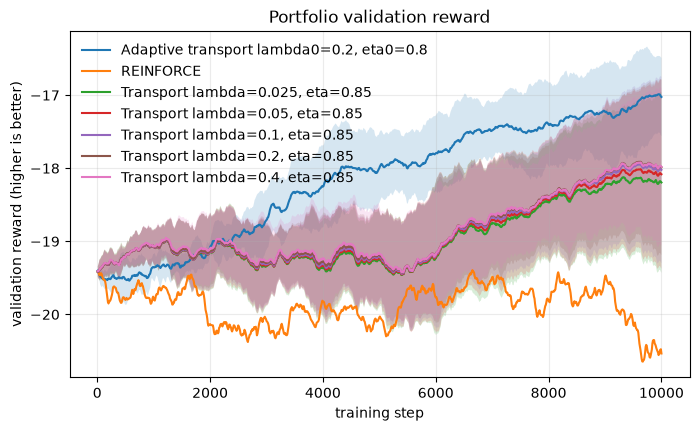

In [2]:
if not runs:
    print('No saved runs yet. Run scripts/run.py before executing the analysis cells.')
else:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_validation_rewards(runs, env=ENV, horizon=10, flow='exact', ax=ax)
    ax.set_title('Portfolio validation reward')
    plt.show()

## Wealth Mean and Variance Flow

Population wealth mean and variance induced by the best saved policy for each algorithm and perturbation level.

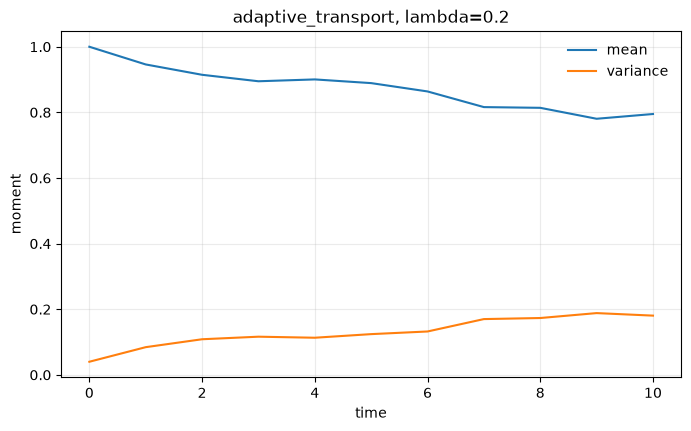

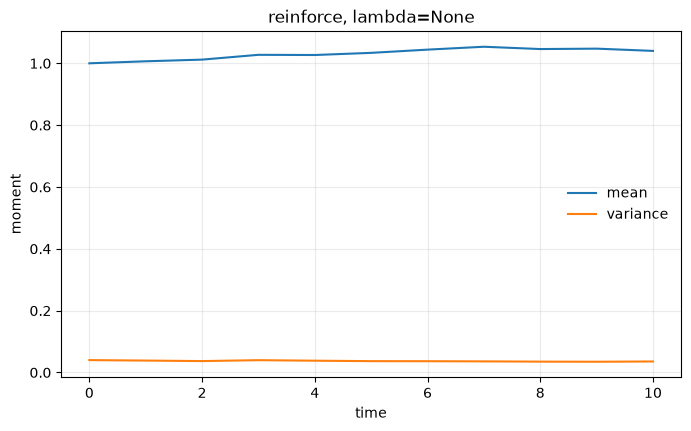

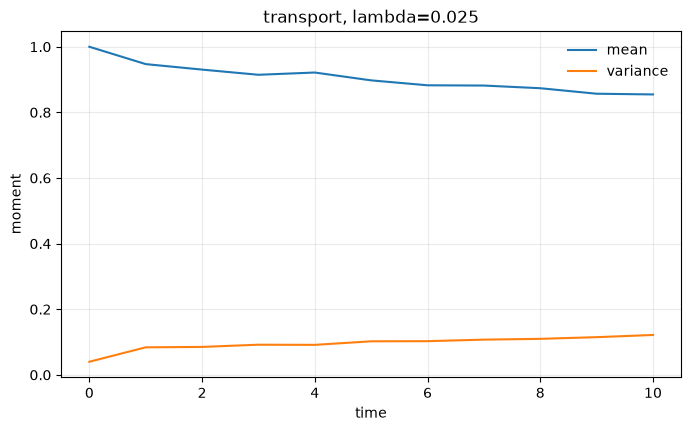

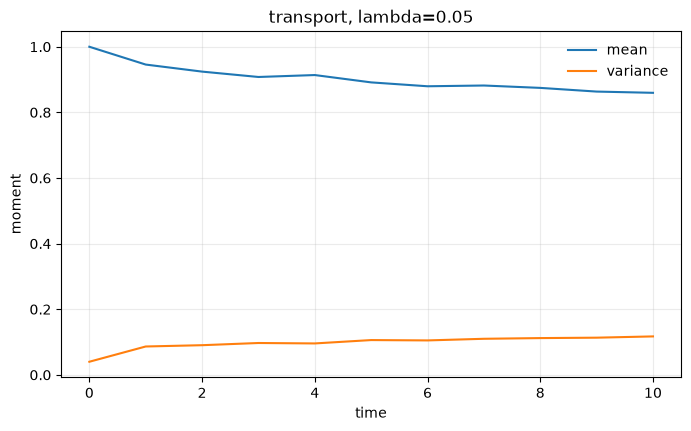

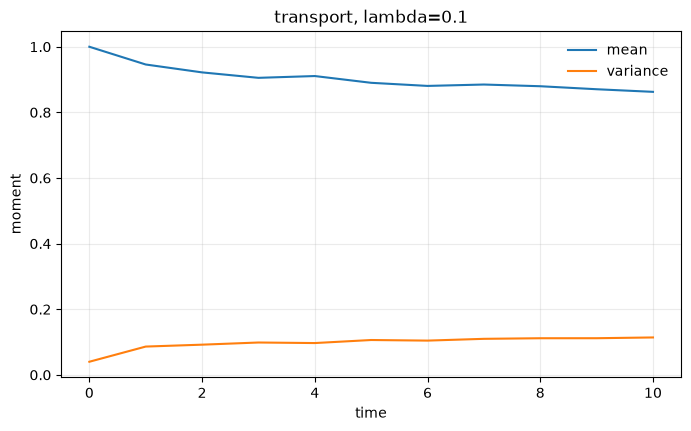

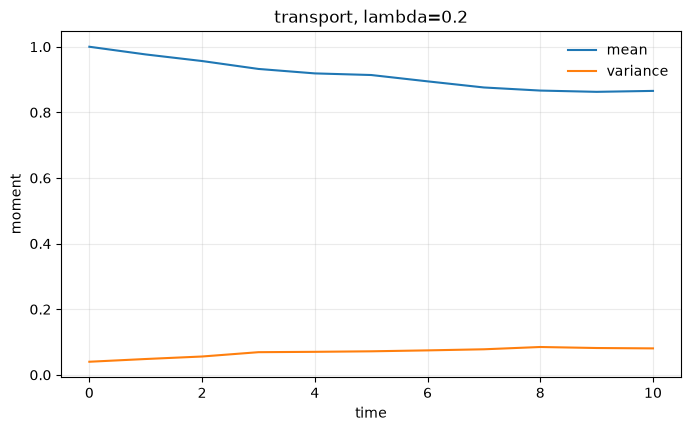

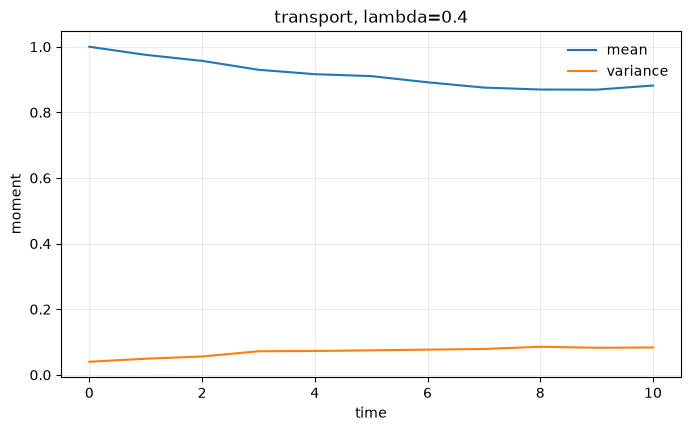

In [3]:
for run in best_runs_by_label(runs):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_state_flow(run, ax=ax)
    meta = run['metadata']
    ax.set_title(f"{meta['algorithm']}, lambda={meta['perturbation']}")
    plt.show()

## Objective Table: J vs J^lambda

Closed-form objective values at the learned policy, with the analytical unperturbed optimum included when available.

In [4]:
display(objective_table(runs))

,env,label,flow,horizon,eta,seed,validation_reward,objective_convention,J0,Jlambda,J0_star,Jlambda_star
0,portfolio,"Adaptive transport lambda0=0.2, eta0=0.8",exact,10,0.962314,0,-17.205701,reward,-17.205701,-19.383268,-13.132955,-15.050015
1,portfolio,"Adaptive transport lambda0=0.2, eta0=0.8",exact,10,0.965906,1,-16.647958,reward,-16.647958,-18.745028,-13.132955,-15.050015
2,portfolio,"Adaptive transport lambda0=0.2, eta0=0.8",exact,10,0.965937,2,-17.888128,reward,-17.888128,-20.195608,-13.132955,-15.050015
3,portfolio,"Adaptive transport lambda0=0.2, eta0=0.8",exact,10,0.965712,3,-16.644926,reward,-16.644926,-18.819114,-13.132955,-15.050015
4,portfolio,"Adaptive transport lambda0=0.2, eta0=0.8",exact,10,0.965166,4,-16.738453,reward,-16.738453,-18.896828,-13.132955,-15.050015
5,portfolio,REINFORCE,exact,10,NaN,0,-20.532095,reward,-20.532095,NaN,-13.132955,NaN
6,portfolio,REINFORCE,exact,10,NaN,1,-20.530753,reward,-20.530753,NaN,-13.132955,NaN
7,portfolio,REINFORCE,exact,10,NaN,2,-20.533404,reward,-20.533404,NaN,-13.132955,NaN
8,portfolio,REINFORCE,exact,10,NaN,3,-20.538542,reward,-20.538542,NaN,-13.132955,NaN
9,portfolio,REINFORCE,exact,10,NaN,4,-20.540302,reward,-20.540302,NaN,-13.132955,NaN


## Transport Gradient Diagnostics

Optional Monte Carlo check of bias, MSE, cosine similarity, and perturbation bias against the exact portfolio gradient oracle.

In [5]:
RUN_GRADIENT_DIAGNOSTICS = True
N_REPLICATIONS = 20

if RUN_GRADIENT_DIAGNOSTICS:
    tables = []
    for run in runs:
        try:
            tables.append(gradient_diagnostics(run, n_replications=N_REPLICATIONS))
        except ValueError:
            pass
    display(pd.concat(tables, ignore_index=True) if tables else pd.DataFrame())
else:
    print('Set RUN_GRADIENT_DIAGNOSTICS = True to recompute gradient bias/MSE diagnostics.')

,env,label,flow,horizon,lambda,eta,n_parameters,diagnostic_n_particles,n_replications,bias_norm,...,bias_z,bias_z_null_rms,bias_chi2_stat,bias_chi2_df,bias_chi2_pvalue,mse,cosine_similarity,exact_gradient_norm,estimate_gradient_norm_mean,perturbation_bias_norm
0,portfolio,"Transport lambda=0.025, eta=0.85",exact,10,0.025,0.85,20,311,20,64.104338,...,0.683381,1.0,9.340186,20,0.978622,8564.825999,-0.093380,1.393130,399.890237,0.001780
1,portfolio,"Transport lambda=0.025, eta=0.85",exact,10,0.025,0.85,20,311,20,41.454057,...,0.503619,1.0,5.072633,20,0.999690,6522.487949,0.105405,1.121356,352.857576,0.001517
2,portfolio,"Transport lambda=0.025, eta=0.85",exact,10,0.025,0.85,20,311,20,40.982676,...,0.551942,1.0,6.092797,20,0.998766,5321.641268,0.067476,0.842469,309.654910,0.001451
3,portfolio,"Transport lambda=0.025, eta=0.85",exact,10,0.025,0.85,20,311,20,45.348533,...,0.534883,1.0,5.721989,20,0.999224,6931.446773,0.021231,1.142920,355.620213,0.001488
4,portfolio,"Transport lambda=0.025, eta=0.85",exact,10,0.025,0.85,20,311,20,39.982678,...,0.535367,1.0,5.732361,20,0.999214,5378.564006,0.149551,0.888125,315.383392,0.001529
5,portfolio,"Transport lambda=0.05, eta=0.85",exact,10,0.050,0.85,20,311,20,58.738118,...,0.622196,1.0,7.742555,20,0.993439,8639.114642,-0.105314,1.400230,406.224314,0.007063
6,portfolio,"Transport lambda=0.05, eta=0.85",exact,10,0.050,0.85,20,311,20,37.929342,...,0.474775,1.0,4.508217,20,0.999877,6135.097529,0.096124,1.095144,343.913744,0.006008
7,portfolio,"Transport lambda=0.05, eta=0.85",exact,10,0.050,0.85,20,311,20,33.406023,...,0.468810,1.0,4.395652,20,0.999900,4879.492886,0.044230,0.839462,303.237345,0.005750
8,portfolio,"Transport lambda=0.05, eta=0.85",exact,10,0.050,0.85,20,311,20,37.019166,...,0.481495,1.0,4.636752,20,0.999847,5684.080400,0.016104,1.138406,329.448516,0.006034
9,portfolio,"Transport lambda=0.05, eta=0.85",exact,10,0.050,0.85,20,311,20,35.249091,...,0.492973,1.0,4.860440,20,0.999778,4919.189506,0.179064,0.885547,305.539664,0.006009


## Missing Mean-Field Correction Term

Optional diagnostic comparing the full transport gradient with the policy-only term. The difference is the mean-field correction absent from classical REINFORCE.

In [6]:
RUN_CORRECTION_DIAGNOSTIC = True

if RUN_CORRECTION_DIAGNOSTIC:
    tables = []
    for run in runs:
        try:
            tables.append(transport_correction_table(run, n_replications=N_REPLICATIONS))
        except ValueError:
            pass
    display(pd.concat(tables, ignore_index=True) if tables else pd.DataFrame())
else:
    print('Set RUN_CORRECTION_DIAGNOSTIC = True to estimate the missing correction term.')

,env,label,flow,horizon,seed,lambda,eta,replication,full_gradient_norm,policy_only_gradient_norm,...,correction_mean_norm,correction_std,correction_se,correction_z,correction_z_null_rms,correction_chi2_stat,correction_chi2_df,correction_chi2_pvalue,correction_mean_fraction,full_policy_mean_cosine
0,portfolio,"Transport lambda=0.025, eta=0.85",exact,10,0,0.025,0.85,0,278.286152,98.387732,...,102.606780,662.679155,148.179564,0.692449,1.0,9.58971,20,0.975016,1.000124,0.138042
1,portfolio,"Transport lambda=0.025, eta=0.85",exact,10,0,0.025,0.85,1,425.682681,46.484760,...,102.606780,662.679155,148.179564,0.692449,1.0,9.58971,20,0.975016,1.000124,0.138042
2,portfolio,"Transport lambda=0.025, eta=0.85",exact,10,0,0.025,0.85,2,398.623458,128.232459,...,102.606780,662.679155,148.179564,0.692449,1.0,9.58971,20,0.975016,1.000124,0.138042
3,portfolio,"Transport lambda=0.025, eta=0.85",exact,10,0,0.025,0.85,3,649.079563,85.289677,...,102.606780,662.679155,148.179564,0.692449,1.0,9.58971,20,0.975016,1.000124,0.138042
4,portfolio,"Transport lambda=0.025, eta=0.85",exact,10,0,0.025,0.85,4,345.223933,154.506435,...,102.606780,662.679155,148.179564,0.692449,1.0,9.58971,20,0.975016,1.000124,0.138042
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,portfolio,"Transport lambda=0.4, eta=0.85",exact,10,4,0.400,0.85,15,437.945885,234.685284,...,52.416602,400.872308,89.637773,0.584760,1.0,6.83889,20,0.997181,0.932866,0.434019
496,portfolio,"Transport lambda=0.4, eta=0.85",exact,10,4,0.400,0.85,16,418.961579,208.874186,...,52.416602,400.872308,89.637773,0.584760,1.0,6.83889,20,0.997181,0.932866,0.434019
497,portfolio,"Transport lambda=0.4, eta=0.85",exact,10,4,0.400,0.85,17,331.092846,207.485018,...,52.416602,400.872308,89.637773,0.584760,1.0,6.83889,20,0.997181,0.932866,0.434019
498,portfolio,"Transport lambda=0.4, eta=0.85",exact,10,4,0.400,0.85,18,541.559796,205.012037,...,52.416602,400.872308,89.637773,0.584760,1.0,6.83889,20,0.997181,0.932866,0.434019


## Runtime Table

Average elapsed time and estimated simulator budget for each algorithm configuration.

In [7]:
display(runtime_table(runs))

,env,algorithm,perturbation,eta,horizon,flow,setup_seconds_mean,setup_seconds_std,train_step_seconds_mean,train_step_seconds_std,validation_seconds_mean,validation_seconds_std,elapsed_seconds_mean,elapsed_seconds_std,seconds_per_step_mean,wall_seconds_per_step_mean,validation_seconds_per_call_mean,simulator_budget_mean,n_runs
0,portfolio,adaptive_transport,0.200,NaN,10,exact,9.281602,0.972494,335.234384,10.266922,1.163820,0.045064,345.709129,9.348838,0.033523,0.034571,0.001164,5108.4,5
1,portfolio,reinforce,NaN,NaN,10,exact,8.208404,0.514091,49.933351,1.556085,1.224742,0.031527,59.396780,1.550519,0.004993,0.005940,0.001225,5110.0,5
2,portfolio,transport,0.025,0.85,10,exact,8.153225,0.305421,338.815787,1.263864,1.233429,0.062039,348.232754,1.552512,0.033882,0.034823,0.001233,5110.0,5
3,portfolio,transport,0.050,0.85,10,exact,10.305817,1.567240,335.744544,1.654964,1.199705,0.045212,347.279925,2.188562,0.033574,0.034728,0.001200,5110.0,5
4,portfolio,transport,0.100,0.85,10,exact,8.802167,0.401344,341.602798,1.611686,1.254907,0.032482,351.692011,1.765902,0.034160,0.035169,0.001255,5110.0,5
5,portfolio,transport,0.200,0.85,10,exact,9.489519,1.755097,337.610169,2.926458,1.276394,0.051128,348.411871,4.329642,0.033761,0.034841,0.001276,5110.0,5
6,portfolio,transport,0.400,0.85,10,exact,8.486441,0.415512,324.029511,4.693805,1.217489,0.031828,333.766201,4.530503,0.032403,0.033377,0.001217,5110.0,5
